In [1]:
print("sup  bitch ")

sup  bitch 


##IMPORT THE MNIST DATASET

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
X ,y = mnist["data"] , mnist["target"]

In [4]:
X.shape

(70000, 784)

In [5]:
y.shape

(70000,)

##Let's look at one of the digits

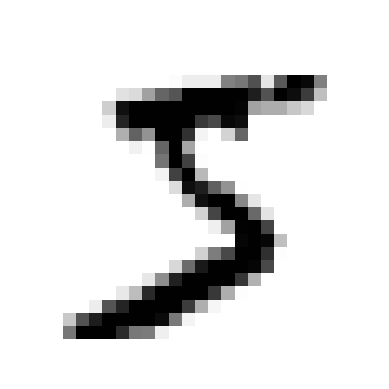

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Update this line to use Pandas indexing and convert to NumPy
some_digit = X.iloc[0].to_numpy() 
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [7]:
y[0]

'5'

#this is indeed a 5 

#Note that the label is a string. Most ML algorithms expect numbers, so let’s cast y to
integer:

In [8]:
import numpy as np
y = y.astype(np.uint8)

In [9]:
print(y[0])

5


In [10]:
type(y[0])

numpy.uint8

#You should always create a test set and set it aside before inspecting the data
closely. The MNIST dataset is actually already split into a training set (the first 60,000
images) and a test set (the last 10,000 images):

##TRAINING A BINARY CLASSIFIER 


This “5-detector” will be an example of a binary classifier, capable of
distinguishing between just two classes, 5 and not-5. Let’s create the target vectors for
this classification task

In [11]:
X_train , X_test ,y_train , y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [12]:
y_train_5 = (y_train == 5) # True for all 5s, False for all other digits
y_test_5 = (y_test == 5)

Now let’s pick a classifier and train it.

Now let’s pick a classifier and train it. 
    This classifier
has the advantage of being capable of handling very large datasets efficiently.This is
in part because SGD deals with training instances independently, one at a time
(which also makes SGD well suited for online learning),

In [13]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train , y_train_5)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

The SGDClassifier relies on randomness during training (hence
the name “stochastic”). If you want reproducible results, you
should set the random_state parameter.

Now we can use it to detect images of the number 5:

In [14]:
sgd_clf.predict([some_digit])

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

Now, let’s evaluate this model’s performance.

##Performance Measures

Evaluating a classifier is often significantly trickier than evaluating a regressor, so we
will spend a large part of this chapter on this topic. There are many performance
measures available, so grab another coffee and get ready to learn many new concepts
and acronyms!

#Measuring Accuracy Using Cross-Validation

Let’s use the cross_val_score() function to evaluate our SGDClassifier model,
using K-fold cross-validation with three folds. Remember that K-fold cross-validation
means splitting the training set into K folds (in this case, three), then making predictions
and evaluating them on each fold using a model trained on the remaining folds

In [15]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf , X_train , y_train_5 , cv = 3 , scoring = "accuracy")

array([0.95035, 0.96035, 0.9604 ])

Well, before you get too excited, let’s look at a very
dumb classifier that just classifies every single image in the “not-5” class:

In [16]:
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [17]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

##Confusion Matrix 

A much better way to evaluate the performance of a classifier is to look at the confusion
matrix.The general idea is to count the number of times instances of class A are
classified as class B. For example, to know the number of times the classifier confused
images of 5s with 3s, you would look in the fifth row and third column of the confusion
matrix.

To compute the confusion matrix, you first need to have a set of predictions so that
they can be compared to the actual targets. You could make predictions on the test
set, but let’s keep it untouched for now (remember that you want to use the test set
only at the very end of your project, once you have a classifier that you are ready to
launch). Instead, you can use the cross_val_predict() function:

However, you should not just use the standard .predict() method on your training set. If the model predicts on the exact same data it was trained on, it will look artificially smart (overfitting).

In [18]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

Just like the cross_val_score() function, cross_val_predict() performs K-fold
cross-validation, but instead of returning the evaluation scores, it returns the predictions
made on each test fold. This means that you get a clean prediction for each
instance in the training set (“clean” meaning that the prediction is made by a model
that never saw the data during training).

In [19]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5 , y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

Each row in a confusion matrix represents an actual class, while each column represents
a predicted class. The first row of this matrix considers non-5 images (the negative
class): 53,057 of them were correctly classified as non-5s (they are called true
negatives), while the remaining 1,522 were wrongly classified as 5s (false positives).
The second row considers the images of 5s (the positive class): 1,325 were wrongly
classified as non-5s (false negatives), while the remaining 4,096 were correctly classified
as 5s (true positives).

A perfect classifier would have only true positives and true
negatives, so its confusion matrix would have nonzero values only on its main diagonal
(top left to bottom right):

In [20]:
#lets pretend that the predictions (the classifier isprefect) ; give the confusion matrix for that
y_train_perfect = y_train_5 
confusion_matrix(y_train_perfect , y_train_5)

array([[54579,     0],
       [    0,  5421]])

The confusion matrix gives you a lot of information, but sometimes you may prefer a
more concise metric. An interesting one to look at is the accuracy of the positive predictions;
this is called the precision of the classifier (Equation 3-1).

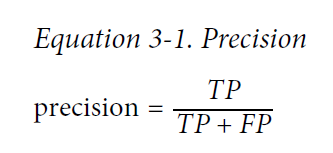

TP is the number of true positives, and FP is the number of false positives.
A trivial way to have perfect precision is to make one single positive prediction and
ensure it is correct (precision = 1/1 = 100%). But this would not be very useful, since
the classifier would ignore all but one positive instance. So precision is typically used
along with another metric named recall, also called sensitivity or the true positive rate
(TPR): this is the ratio of positive instances that are correctly detected by the classifier
(Equation 3-2).

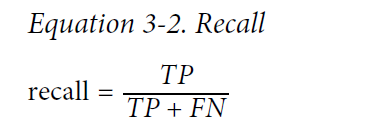

#Precisoion and recall 

In [21]:
from sklearn.metrics import precision_score , recall_score
precision_score (y_train_5 , y_train_pred)#4344/(4344+1307)

0.8370879772350012

In [22]:
recall_score(y_train_5 , y_train_pred)

0.6511713705958311

It is often convenient to combine precision and recall into a single metric called the F1
score, in particular if you need a simple way to compare two classifiers. The F1 score is
the harmonic mean of precision and recall


As a result, the classifier will only get a high F1 score if both recall and precision are
high.

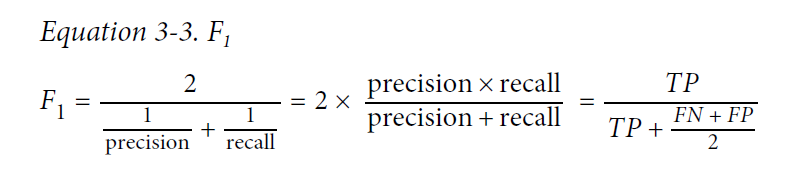

In [23]:
from sklearn.metrics import f1_score
f1_score(y_train_5 , y_train_pred)

0.7325171197343847

The F1 score favors classifiers that have similar precision and recall. This is not always
what you want: in some contexts you mostly care about precision, and in other contexts
you really care about recall.

Unfortunately, you can’t have it both ways: increasing precision reduces recall, and
vice versa. This is called the precision/recall trade-off.

For example, if you trained a classifier to detect videos
that are safe for kids, you would probably prefer a classifier that rejects many
good videos (low recall) but keeps only safe ones (high precision), rather than a classifier
that has a much higher recall but lets a few really bad videos show up in your
product (in such cases, you may even want to add a human pipeline to check the classifier’s
video selection). On the other hand, suppose you train a classifier to detect
shoplifters in surveillance images: it is probably fine if your classifier has only 30%
precision as long as it has 99% recall (sure, the security guards will get a few false
alerts, but almost all shoplifters will get caught).

#Precision/Recall Tradeoff

Conversely, lowering
the threshold increases recall and reduces precision.
Performance

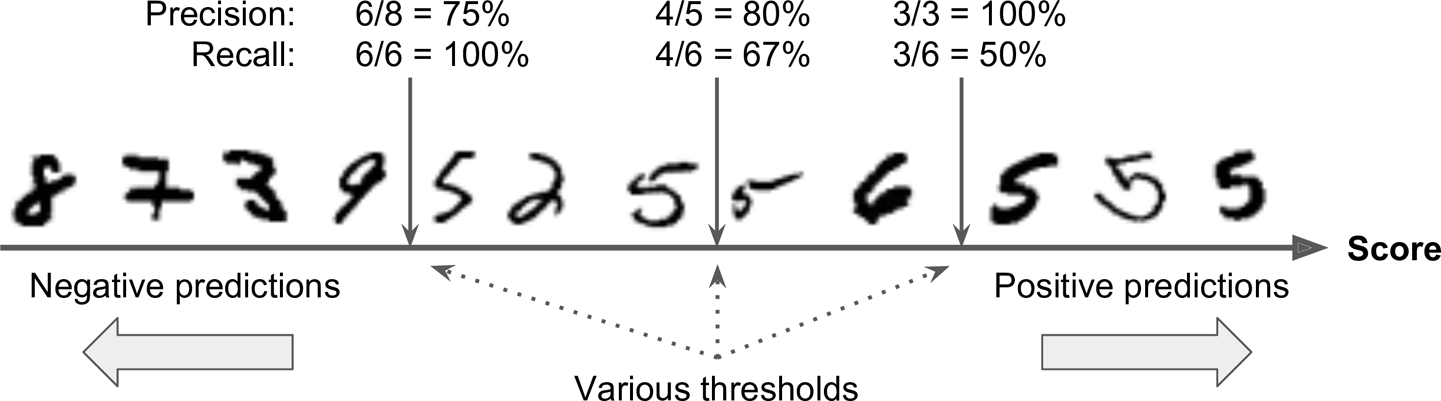

Scikit-Learn does not let you set the threshold directly, but it does give you access to
the decision scores that it uses to make predictions. Instead of calling the classifier’s
predict() method, you can call its decision_function() method, which returns a
score for each instance, and then use any threshold you want to make predictions
based on those scores:

In [24]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([2164.22030239])

In [25]:
#lets practically examine the tradeoff by altering the threshold 
threshold = 0 
y_some_digits_pred = (y_scores > threshold)
y_some_digits_pred

array([ True])

The SGDClassifier uses a threshold equal to 0, so the previous code returns the same
result as the predict() method (i.e., True). Let’s raise the threshold:

In [26]:
threshold = 8000 
y_some_digits_pred = (y_scores > threshold)
y_some_digits_pred

array([False])

This confirms that raising the threshold decreases recall. The image actually represents
a 5, and the classifier detects it when the threshold is 0, but it misses it when the
threshold is increased to 8,000.

How do you decide which threshold to use? First, use the cross_val_predict()
function to get the scores of all instances in the training set, but this time specify that
you want to return decision scores instead of predictions:

In [27]:
y_scores = cross_val_predict(sgd_clf,X_train , y_train_5 , cv=3 , method = "decision_function")

With these scores, use the precision_recall_curve() function to compute precision
and recall for all possible thresholds (well it's just a graph that gives the relationship b/w precission and recall on various threshold values)

In [28]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [29]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.axis([-50000, 50000, 0, 1])
    [...] # highlight the threshold and add the legend, axis label, and grid

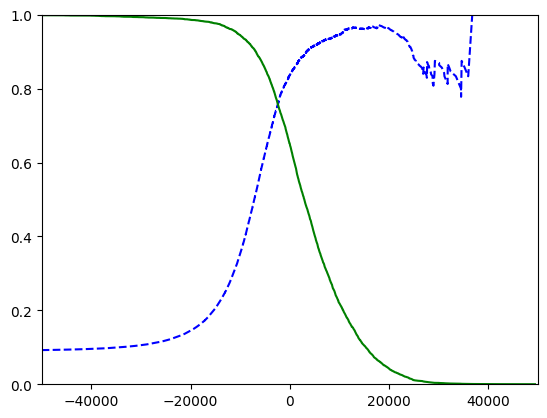

In [30]:
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

NameError: name 'recall_90_precision' is not defined

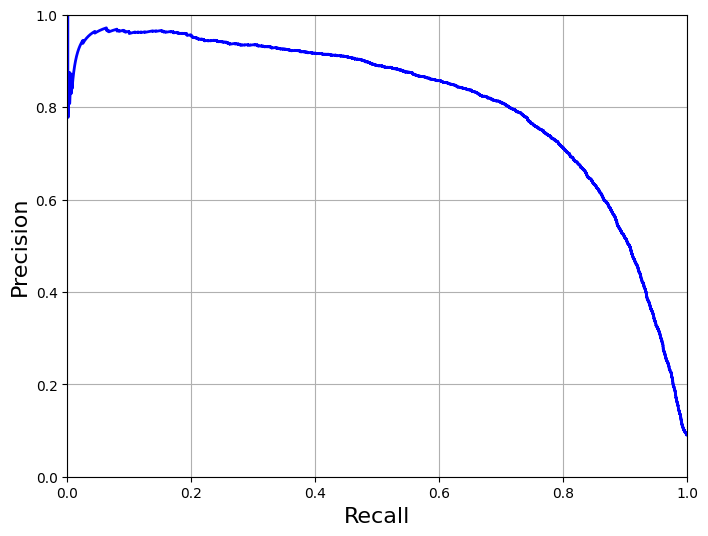

In [31]:
import matplotlib.pyplot as plt

def plot_precision_vs_recall(precisions, recalls):
    # Plot recall on the x-axis and precision on the y-axis
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    
    # Lock the axes from 0 to 1 since both metrics are percentages
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)

# Highlight the threshold we found earlier (90% precision)
# Assuming you still have recall_90_precision calculated from the previous step
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")

plt.show()

In [32]:
##well it is to be noted that significant progress needed pyplot learning


#well we want a precision of 90% , so let's find out the threshold for such condtion  

To be more precise you can search for the
lowest threshold that gives you at least 90% precision (np.argmax() will give you the
first index of the maximum value, which in this case means the first True value):

In [33]:
threshold_90_precisoion = thresholds[np.argmax(precisions >= 0.90)]
threshold_90_precisoion

np.float64(3370.0194991439557)

##ROC Curve

The receiver operating characteristic (ROC) curve is another common tool used with
binary classifiers. It is very similar to the precision/recall curve, but instead of plotting
precision versus recall, the ROC curve plots the true positive rate (another name
for recall) against the false positive rate (FPR). The FPR is the ratio of negative instances
that are incorrectly classified as positive. It is equal to 1 – the true negative rate
(TNR), which is the ratio of negative instances that are correctly classified as negative.
The TNR is also called specificity. Hence, the ROC curve plots sensitivity (recall) versus
1 – specificity.

To plot the ROC curve, you first use the roc_curve() function to compute the TPR
and FPR for various threshold values:

In [34]:
from sklearn.metrics import roc_curve

fpr , tpr, thresholds = roc_curve(y_train_5 , y_scores)

In [35]:
#now plot the graph for both 
def plot_roc_curve(fpr , tpr , label = None):
    plt.plot(fpr , tpr , linewidth=2 , label = label)
    plt.plot ([0,1],[0,1],'k--')
    plt.axis([0,1,0,1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

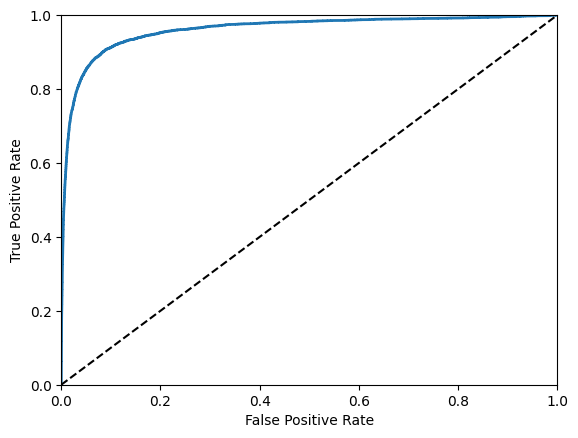

In [36]:
plot_roc_curve(fpr,tpr )


A perfect
classifier will have a ROC AUC equal to 1, whereas a purely random classifier will
have a ROC AUC equal to 0.5. Scikit-Learn provides a function to compute the ROC
AUC

In [37]:
from sklearn.metrics import roc_auc_score 
roc_auc_score(y_train_5 , y_scores)

0.9604938554008616

#Note 
Since the ROC curve is so similar to the precision/recall (PR)
curve, you may wonder how to decide which one to use. As a rule
of thumb, you should prefer the PR curve whenever the positive
class is rare or when you care more about the false positives than
the false negatives. Otherwise, use the ROC curve. For example,
looking at the previous ROC curve (and the ROC AUC score), you
may think that the classifier is really good. But this is mostly
because there are few positives (5s) compared to the negatives
(non-5s). In contrast, the PR curve makes it clear that the classifier
has room for improvement (the curve could be closer to the topleft
corner).

lets trian a randomForestClassifier and compare its roc auc score to sgdclassifier  , for plotting the curve u need scores for each instance which we used to do with the help of decision_function() but randomforestclassifier doesn't have in its place it has predict_proba() method which returns a array containing percantage chancees but we need scores so.... we use the positive class's probablity as the score 

In [38]:
from sklearn.ensemble import RandomForestClassifier 

forest_clf = RandomForestClassifier(random_state = 42)
y_probas_forest = cross_val_predict(forest_clf , X_train , y_train_5 , cv = 3 , method = "predict_proba")

In [39]:
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5,y_scores_forest)

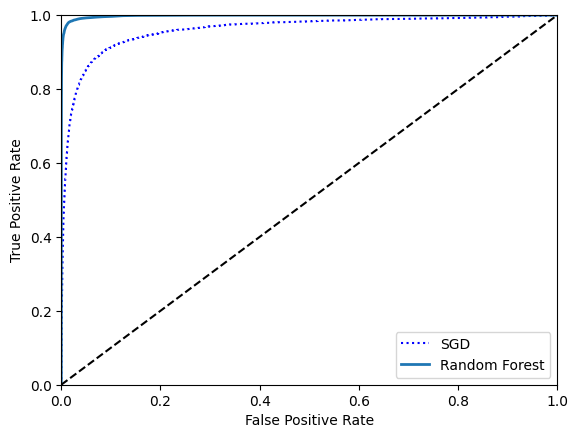

In [40]:
plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

In [41]:
roc_auc_score(y_train_5 , y_scores_forest)

0.9983436731328145

In [42]:
# Generate standard predictions directly (defaults to a 0.5 threshold)
y_train_pred_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3)

# Then measure
precision_score(y_train_5, y_train_pred_forest)
recall_score(y_train_5, y_train_pred_forest)

0.8662608374838591

You now know how to train binary classifiers, choose the appropriate metric for your
task, evaluate your classifiers using cross-validation, select the precision/recall tradeoff
that fits your needs, and use ROC curves and ROC AUC scores to compare various
models. Now let’s try to detect more than just the 5s.

##Multiclass Classification

Whereas binary classifiers distinguish between two classes, multiclass classifiers (also
called multinomial classifiers) can distinguish between more than two classes.

Native vs. Binary-Only AlgorithmsNative Multiclass: Some algorithms can handle multiple classes out of the box (e.g., SGD classifiers, Random Forest classifiers, Naive Bayes).Strictly Binary: Other algorithms are designed only for binary classification (e.g., Logistic Regression, Support Vector Machines). However, they can be adapted for multiclass tasks using specific strategies.Strategies for Using Binary Classifiers for Multiclass Tasks1. One-Versus-the-Rest (OvR) / One-Versus-AllHow it works: You train one binary classifier for each class (e.g., for digits 0-9, you train 10 classifiers: a 0-detector, 1-detector, etc.).Prediction: You get the decision score from each classifier and select the class with the highest score.When to use: This is the preferred strategy for most binary classification algorithms.2. One-Versus-One (OvO)How it works: You train a binary classifier for every possible pair of classes (e.g., 0 vs. 1, 0 vs. 2, 1 vs. 2).The Math: For $N$ classes, you need to train $N \times (N - 1) / 2$ classifiers. For example, a 10-class problem like MNIST requires 45 separate binary classifiers.Prediction: You run the input through all the classifiers and choose the class that wins the most "duels."Advantage: Each individual classifier only needs to be trained on the subset of data containing its specific two classes.When to use: Preferred for algorithms that scale poorly with the size of the training set (like SVMs). Training many classifiers on small datasets is much faster for these algorithms than training a few classifiers on large datasets.

Scikit-Learn detects when you try to use a binary classification algorithm for a multiclass
classification task, and it automatically runs OvR or OvO, depending on the
algorithm. Let’s try this with a Support Vector Machine classifier (see Chapter 5),
using the sklearn.svm.SVC class:

lets look under the hood using decision_function([some_digit])

if u want to force scikit-learn to use OVO or one versus all , u can simply use OneVsOne classifier or OneVsRestClassifier, let's create an instance 

In [43]:
#training an sgdclassifier is just as easy 
sgd_clf.fit(X_train[:200] , y_train[:200])#had to train on just 200 images to prevent comp freezing
sgd_clf.predict([some_digit])

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([5], dtype=uint8)

This time Scikit-Learn did not have to run OvR or OvO because SGD classifiers can
directly classify instances into multiple classes. The decision_function() method
now returns one value per class. Let’s look at the score that the SGD classifier assigned
to each class:

In [44]:
sgd_clf.decision_function([some_digit])

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([[-186473.20516111, -254830.5972183 , -301609.55304214,
        -101322.98985458, -315273.68019387,  144600.99755543,
        -215952.37421406, -226167.15622402, -176131.88697398,
        -404522.96244212]])

Now of course you want to evaluate this
classifier. As usual, you can use cross-validation. Use the cross_val_score() function
to evaluate the SGDClassifier’s accuracy:

In [45]:
cross_val_score(sgd_clf , X_train , y_train , cv = 3 , scoring ="accuracy")

array([0.87745, 0.85835, 0.8698 ])

In [46]:
#well 84% is gud but we can do better by using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89835, 0.8902 , 0.90095])

##Error Analysis

we will assume that
you have found a promising model and you want to find ways to improve it. One way
to do this is to analyze the types of errors it makes.

First, look at the confusion matrix. You need to make predictions using the
cross_val_predict() function, then call the confusion_matrix() function, just like
you did earlier:

In [48]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf,X_train_scaled , y_train , cv = 3)
conf_mx = confusion_matrix(y_train ,y_train_pred )
conf_mx

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([[5573,    0,   23,    5,    8,   44,   36,    6,  227,    1],
       [   0, 6398,   37,   24,    4,   43,    4,    7,  214,   11],
       [  29,   25, 5220,   91,   73,   25,   68,   36,  380,   11],
       [  22,   17,  117, 5224,    2,  204,   27,   40,  405,   73],
       [  12,   14,   40,    9, 5181,   12,   34,   25,  351,  164],
       [  26,   15,   29,  165,   53, 4445,   74,   14,  541,   59],
       [  30,   15,   43,    3,   43,   96, 5551,    3,  133,    1],
       [  20,    9,   51,   29,   49,   12,    3, 5680,  200,  212],
       [  18,   64,   47,   89,    3,  124,   25,   10, 5426,   45],
       [  23,   18,   30,   65,  117,   37,    1,  179,  387, 5092]])

well that's a lot of numbers , so we use matplot's matshow()

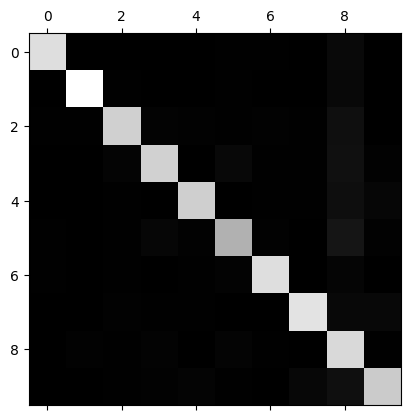

In [49]:
plt.matshow(conf_mx , cmap = plt.cm.gray)
plt.show()

This confusion matrix looks pretty good, since most images are on the main diagonal,
which means that they were classified correctly. The 5s look slightly darker than
the other digits, which could mean that there are fewer images of 5s in the dataset or
that the classifier does not perform as well on 5s as on other digits. In fact, you can
verify that both are the case.

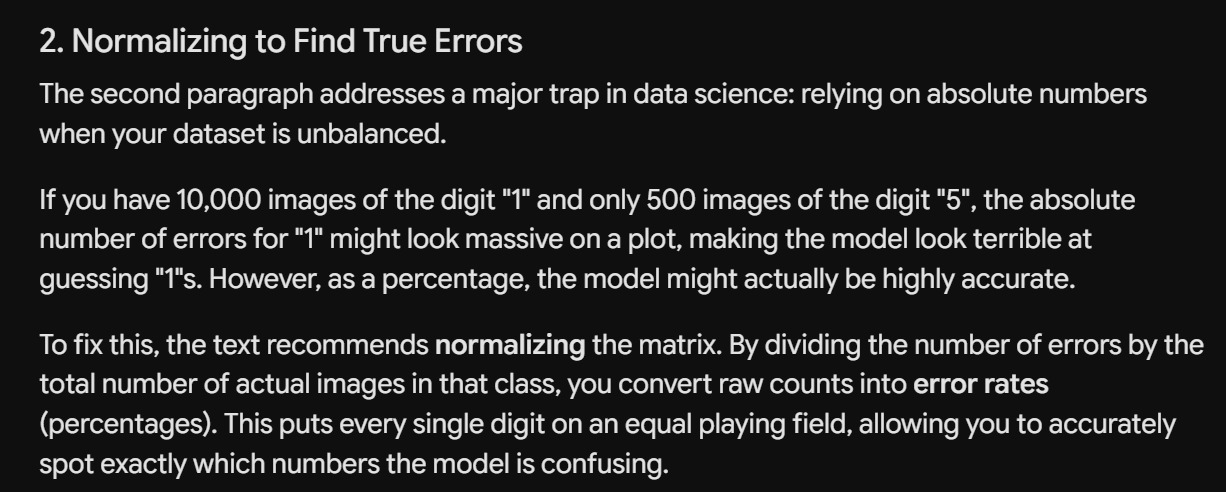

In [50]:
row_sums = conf_mx.sum(axis = 1 , keepdims = True)
norm_conf_mx = conf_mx/row_sums

In [52]:
norm_conf_mx                #nvm

array([[9.40908323e-01, 0.00000000e+00, 3.88316731e-03, 8.44166807e-04,
        1.35066689e-03, 7.42866790e-03, 6.07800101e-03, 1.01300017e-03,
        3.83251731e-02, 1.68833361e-04],
       [0.00000000e+00, 9.48976565e-01, 5.48798576e-03, 3.55977455e-03,
        5.93295758e-04, 6.37792940e-03, 5.93295758e-04, 1.03826758e-03,
        3.17413230e-02, 1.63156333e-03],
       [4.86740517e-03, 4.19603894e-03, 8.76132931e-01, 1.52735817e-02,
        1.22524337e-02, 4.19603894e-03, 1.14132259e-02, 6.04229607e-03,
        6.37797919e-02, 1.84625713e-03],
       [3.58832164e-03, 2.77279400e-03, 1.90833469e-02, 8.52063285e-01,
        3.26211059e-04, 3.32735280e-02, 4.40384929e-03, 6.52422117e-03,
        6.60577394e-02, 1.19067036e-02],
       [2.05409106e-03, 2.39643958e-03, 6.84697022e-03, 1.54056830e-03,
        8.86853817e-01, 2.05409106e-03, 5.81992468e-03, 4.27935638e-03,
        6.00821636e-02, 2.80725779e-02],
       [4.79616307e-03, 2.76701716e-03, 5.34956650e-03, 3.04371887e-02,
   

<function matplotlib.pyplot.show(close=None, block=None)>

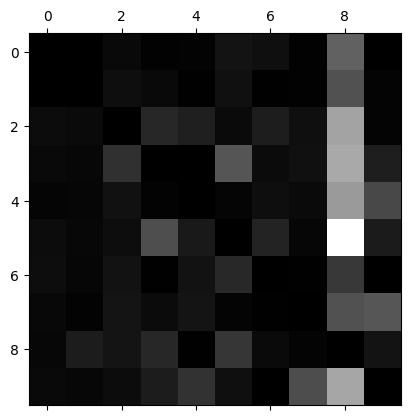

In [53]:
#Fill the diagonal with zeros to keep only the errors, and plot the result:
np.fill_diagonal(norm_conf_mx , 0)
plt.matshow(norm_conf_mx , cmap =plt.cm.gray)
plt.show

Remember that rows represent
actual classes, while columns represent predicted classes.`

The column for class
8 is quite bright, which tells you that many images get misclassified as 8s .the row for class 8 is not that bad, telling you that actual 8s in general get properly
classified as 8s. As you can see, the confusion matrix is not necessarily symmetrical.

#Analyzing the confusion matrix often gives you insights into ways to improve your
classifier. Looking at this plot, it seems that your efforts should be spent on reducing
the false 8s. For example, you could try to gather more training data for digits that
look like 8s (but are not) so that the classifier can learn to distinguish them from real
8s. Or you could engineer new features that would help the classifier—for example,
writing an algorithm to count the number of closed loops (e.g., 8 has two, 6 has one, 5
has none). Or you could preprocess the images (e.g., using Scikit-Image, Pillow, or
OpenCV) to make some patterns, such as closed loops, stand out more.

Analyzing individual errors can also be a good way to gain insights on what your
classifier is doing and why it is failing, but it is more difficult and time-consuming.
For example, let’s plot examples of 3s and 5s (the plot_digits() function just uses
Matplotlib’s imshow() function;

In [58]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_digits(instances, images_per_row=5, **options):
    # Convert Pandas DataFrame/Series to a NumPy array if needed
    if hasattr(instances, "values"):
        instances = instances.values

    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size, size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
        
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap=mpl.cm.binary, **options)
    plt.axis("off")

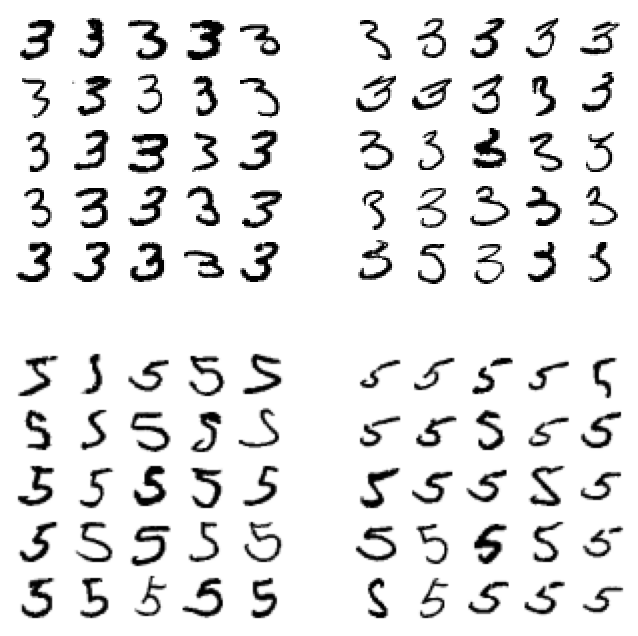

In [59]:
cl_a, cl_b = 3, 5
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]
plt.figure(figsize=(8,8))
plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5)
plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5)
plt.subplot(223); plot_digits(X_ba[:25], images_per_row=5)
plt.subplot(224); plot_digits(X_bb[:25], images_per_row=5)
plt.show()

The SGDClassifier gets easily confused between 3s and 5s because it is a simple linear model that evaluates individual pixel brightness separately instead of understanding full shapes or curves. Since 3 and 5 share almost the exact same pixel structure—a top bar and a bottom arc—they overlap heavily, with the only main difference being a tiny connecting stroke. As a result, if a handwritten 3 is even slightly tilted, rotated, or off-center, its pixels land right where the model expects a 5 to be. The best way to fix this is by preprocessing your images to make sure they are properly centered (or using data augmentation with shifted digits) so minor positional shifts don't trick the classifier.

##Multilabel Classification 

Until now each instance has always been assigned to just one class. In some cases you
may want your classifier to output multiple classes for each instance. Consider a facerecognition
classifier: what should it do if it recognizes several people in the same
picture? It should attach one tag per person it recognizes. Say the classifier has been
trained to recognize three faces, Alice, Bob, and Charlie. Then when the classifier is
shown a picture of Alice and Charlie, it should output [1, 0, 1] (meaning “Alice yes,
Bob no, Charlie yes”). Such a classification system that outputs multiple binary tags is
called a multilabel classification system.

In [61]:
#We won’t go into face recognition just yet, but let’s look at a simpler example, just for illustration purposes
#This code introduces Multilabel Classification, which is where a single model outputs multiple True/False answers at once for a single input,
#instead of predicting just one category

from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier",list,"[array([False, True]), array([False, True])]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [62]:
knn_clf.predict([some_digit])

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([[False,  True]])

In [63]:
#evaluating the multilabel classifier depends on the project , One approach is to measure the F1 score for each
#individual label (or any other binary classifier metric discussed earlier), then simply
#compute the average score. This code computes the average F1 score across all labels:

y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

This assumes that all labels are equally important, however, which may not be the
case. In particular, if you have many more pictures of Alice than of Bob or Charlie,
you may want to give more weight to the classifier’s score on pictures of Alice. One
simple option is to give each label a weight equal to its support (i.e., the number of instances with that target label). To do this, simply set average="weighted" in the
preceding code.

##Multioutput Classification 


The last type of classification task we are going to discuss here is called multioutput– multiclass classification (or simply multioutput classification). It is simply a generalization of multilabel classification where each label can be multiclass (i.e., it can have more than two possible values). To illustrate this, let’s build a system that removes noise from images. It will take as input a noisy digit image, and it will (hopefully) output a clean digit image, represented as an array of pixel intensities, just like the MNIST images. Notice that the classifier’s output is multilabel (one label per pixel) and each label can have multiple values (pixel intensity ranges from 0 to 255). It is thus an example of a multioutput classification system.

#note 
The line between classification and regression is sometimes blurry,
such as in this example. Arguably, predicting pixel intensity is more
akin to regression than to classification. Moreover, multioutput
systems are not limited to classification tasks; you could even have
a system that outputs multiple labels per instance, including both
class labels and value labels.

Let’s start by creating the training and test sets by taking the MNIST images and
adding noise to their pixel intensities with NumPy’s randint() function. The target
images will be the original images:`

In [64]:
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

Let’s take a peek at an image from the test set (yes, we’re snooping on the test data, so
you should be frowning right now):

On the left is the noisy input image, and on the right is the clean target image. Now
let’s train the classifier and make it clean this image

In [65]:
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[some_index]])
plot_digit(clean_digit)

NameError: name 'some_index' is not defined

Looks close enough to the target! This concludes our tour of classification

#You
should now know how to select good metrics for classification tasks, pick the appropriate
precision/recall trade-off, compare classifiers, and more generally build good
classification systems for a variety of tasks.